# Friction Modeling



## Setup from Physically Feasible Dynamic Parameter Identification of the WAM Robot 7-DOF

### to run after setting up Amir's conda env 'id':
- python3 -m pip install sympy==0.7.5
- conda install matplotlib
- conda install scikit-learn

In [1]:
datafolder = 'data/'
tmpfolder = 'tmp/'
from sympy import init_printing
init_printing()

%matplotlib inline
import sympybotics

/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sympybotics-1.0.dev0-py3.8.egg/sympybotics/_compatibility_.py:7: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sympybotics-1.0.dev0-py3.8.egg/sympybotics/_compatibility_.py:11: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sympybotics-1.0.dev0-py3.8.egg/sympybotics/_compatibility_.py:7: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/sympybotics-1.0.dev0-py3.8.egg/sympybotics/_compatibility_.py:11: SyntaxWarning: "is" with a literal. Did you mean "=="?


In [2]:
# rbtdef = sympybotics.RobotDef("WAM Arm 7 DOF",
#             [("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q"),
#              ("pi/2", -0.045, 0, "q"),
#              ("-pi/2", 0, 0.3, "q"),
#              ("pi/2", 0, 0, "q"),
#              (0, 0, 0.06, "q")],
#             dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM 2-DOF",
#     [("-pi/2", 0, 0, "q"),
#      (0, 0.045, 0.55, "q")],
#     dh_convention="standard"
# )

rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
            [("-pi/2", 0, 0, "q"),
             ("pi/2", 0, 0, "q"),
             ("-pi/2", 0.045, 0.55, "q"),
             ("pi/2", -0.045, 0, "q")],
            dh_convention="standard")

# rbtdef = sympybotics.RobotDef("WAM Arm 4 DOF",
#             [(0, 0, 0, "q"),|
#              ("-pi/2", 0, 0, "q"),
#              ("pi/2", 0, 0, "q"),
#              ("-pi/2", 0.045, 0.55, "q")],
#             dh_convention="standard")
rbtdef.frictionmodel = None

In [3]:
import math
import numpy
from math import pi

# Register them in global scope for exec() to see
import builtins
builtins.math = math
builtins.numpy = numpy
builtins.pi = pi

from sympy import iterables


In [4]:
%time rbt = sympybotics.RobotDynCode(rbtdef)
%time rbt.calc_base_parms()

CPU times: user 1.75 s, sys: 6.52 ms, total: 1.76 s
Wall time: 1.76 s
CPU times: user 1.15 s, sys: 126 ms, total: 1.28 s
Wall time: 929 ms


In [5]:
import pickle
with open(tmpfolder + 'robotmodels/wam4_model.pkl', 'wb') as file:
    pickle.dump( rbt, file )

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

rbt.dyn.n_dynparms, rbt.dyn.n_base

rbt.dyn.dynparms.n()
rbt.dyn.baseparms.n()

Matrix([
[                                                 L_1yy + L_2zz],
[L_2xx - L_2zz + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2xy],
[                                                         L_2xz],
[        L_2yy + L_3zz - 1.1*l_3y + 0.300475*m_3 + 0.300475*m_4],
[                                                         L_2yz],
[                                                          l_2x],
[                             l_2z - l_3y + 0.55*m_3 + 0.55*m_4],
[                          L_3xx - L_3zz + L_4zz + 0.002025*m_3],
[                                            L_3xy - 0.045*l_3y],
[                                                         L_3xz],
[                    L_3yy + L_4zz - 0.002025*m_3 - 0.00405*m_4],
[                                                         L_3yz],
[                                  l_3x + 0.045*m_3 + 0.045*m_4],
[                                                   l_3z + l_4y],
[

In [6]:
import numpy as np

# Step 1: Convert symbolic matrix to NumPy array
Pb_matrix = np.array(rbt.dyn.Pb.tolist(), dtype=np.float64)  # already 0/1
Pb_flat = Pb_matrix.flatten()

# Step 2: Generate C++ code
cpp_array_str = 'double Pb[1440] = {\n'
for i, val in enumerate(Pb_flat):
    cpp_array_str += f'{int(val)}, '  # write as integer 0 or 1
    if (i + 1) % 12 == 0:  # break line every 12 entries
        cpp_array_str += '\n'
cpp_array_str += '};'

with open('Pb_array.cpp', 'w') as f:
    f.write(cpp_array_str)

## Load Data

(15000, 4)
(15001, 9)
(15000, 4)


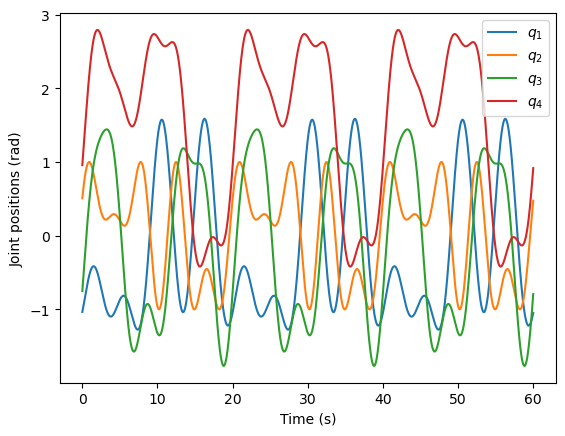

In [7]:
import pickle
import sympybotics
import numpy

with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

h = 0.004
decimate = 1
h_plot = h*decimate # downsample it so that it has the frequency of 500 (originally it has been 1000)

with open(datafolder +  'trajectories/traj_4.dat', 'r' ) as file:
          q_ref_orig = numpy.loadtxt(file)
print(q_ref_orig.shape)
q_ref = q_ref_orig
with open(datafolder +  'recdata/rbtlog_4_dof.dat', 'r' ) as file:
          q_raw_orig = numpy.loadtxt(file)
print(q_raw_orig.shape)
s = q_ref_orig.shape[0] // decimate

q_ref = numpy.zeros((s, rbt.dof))
for i in range(s):
    q_ref[i, :] = q_ref_orig[i*decimate, :]
print(q_ref.shape)

si = 0
sf = si + 60/h_plot
t = numpy.arange(sf-si) * h_plot

from matplotlib import pyplot as plt
plt.close()

si = int(si)
sf = int(sf)

for i in range(rbt.dof):
    plt.plot(t,q_ref[si:sf,i], label="$q_%d$"%(i+1))
plt.legend()

plt.xlabel("Time (s)")
plt.ylabel("Joint positions (rad)")

plt.show()

## Regression Setup



In [8]:
import os
import pickle
import math
import sympy
import numpy
import sympybotics

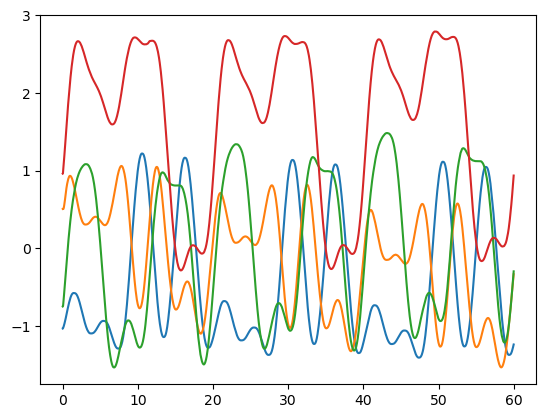

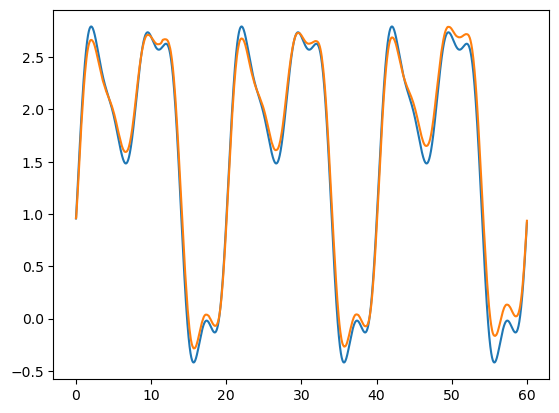

In [9]:
with open(tmpfolder +  'robotmodels/wam4_model.pkl', 'rb' ) as file:
          rbt = pickle.load( file )

from support_funcs.regr_data_proc import read_data
t_raw, q_raw, tau_raw, t_ref, q_ref = read_data( rbt.dof, 0.004,
                                                datafolder + 'recdata/rbtlog_4_dof.dat',
                                                datafolder + 'trajectories/traj_4.dat')
t_raw = t_raw - t_raw[0]

from matplotlib import pyplot as plt
plt.close()

for i in range(q_raw.shape[1]):
    plt.plot(t_raw,q_raw[:,i])

plt.show()

from matplotlib import pyplot as plt
plt.close()

joint = 4
plt.plot(t_ref,q_ref[:,joint-1])
plt.plot(t_raw,q_raw[:,joint-1])

plt.show()

del t_raw, q_raw, tau_raw, t_ref, q_ref

In [10]:
# with open(datafolder +  'trajectories/traj_shwfl_abq0.pkl', 'rb' ) as file:
#           s_h_wf_l, a_b_q0 = pickle.load(file)
with open(datafolder + 'trajectories/traj_shwfl_abq0.pkl', 'rb') as file:
    s_h_wf_l, a_b_q0 = pickle.load(file, encoding='latin1')

print(dict(zip(('S', 'h', 'wf', 'L'), s_h_wf_l)))
print('\n')

fc_mult = 10

wf = float(s_h_wf_l[2])
L = float(s_h_wf_l[3])
fc = fc_mult * ( wf / (2*math.pi) * L )
fc

fc_q = fc
fc_dq = fc
fc_ddq = fc

fc_tau = fc

si = int(3/0.001)
sf = -int(1/0.001)-172

{'S': 500.0, 'h': 0.04, 'wf': 0.3141592653589793, 'L': 5.0}




In [40]:
rec_h = 0.004 # sampling time
from support_funcs.regr_data_proc import read_data, diff_and_filt_data, gen_regr_matrices
from support_funcs.utils import _fprint

t_raw, q_raw, tau_raw, t_ref, q_ref = read_data(dof=rbt.dof, h=rec_h,
                                                rbtlogfile=datafolder + 'recdata/rbtlog_4_dof.dat',
                                                trajreffile=datafolder + 'trajectories/traj_4.dat')

q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

t_raw = t_raw[si:sf]; q_raw = q_raw[si:sf]; tau_raw = tau_raw[si:sf]
q = q[si:sf]; dq = dq[si:sf]; ddq = ddq[si:sf]; tau = tau[si:sf]

t_raw = t_raw - t_raw[0]

t = numpy.array(range(q.shape[0])) * rec_h
print(np.shape(q))
H_S, W, omega, Q1, R1, rho1 = gen_regr_matrices(rbt, q, dq, ddq, tau)

# W is the regression matrix to appropriately find tau_rbd


_fprint(' (cond=%f)'%numpy.linalg.cond(W))

_fprint('save')

%time \
numpy.savez_compressed(tmpfolder + 'procdata/raw', t=t_raw, q=q_raw, tau=tau_raw);\
numpy.savez_compressed(tmpfolder + 'procdata/proc', t=t, q=q, dq=dq, ddq=ddq, tau=tau); \
numpy.savez_compressed(tmpfolder + 'procdata/regr', W=W, omega=omega, Q1=Q1, R1=R1, rho1=rho1)

# del t_raw, q_raw, tau_raw, t, q, dq, ddq, tau, W, omega, Q1, R1, rho1


(10829, 4)
 (cond=35.316812)
save
CPU times: user 458 ms, sys: 6.38 ms, total: 464 ms
Wall time: 469 ms


In [41]:
print("W.shape",W.shape)
print("tau.shape:",tau.shape)
tau_vec = tau.reshape(-1)
print(tau_vec.shape)   # (43316,)

W.shape (43316, 22)
tau.shape: (10829, 4)
(43316,)


In [42]:
# rbt.dyn.baseparms
W.size
tau.size

beta, *_ = np.linalg.lstsq(W, tau_vec, rcond=None)
tau_rbd = W @ beta #friction from the reduced H_S == W regressor model

In [43]:
print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_rbd = tau_rbd.reshape(-1,1)
tau_vec= tau_vec.reshape(-1,1)

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)

tau_residual = tau_vec - tau_rbd

rmse = np.sqrt(np.mean(np.square((tau_residual))))

rmse 
# rbd model:
    #include only viscous ==> rmse = 1.16
    #include both colomnb and viscous ==> rmse = 0.814

tau_rbd.shape (1, 43316)
tau_vec.shape (43316,)
tau_rbd.shape (43316, 1)
tau_vec.shape (43316, 1)


2.6592263411943384

tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


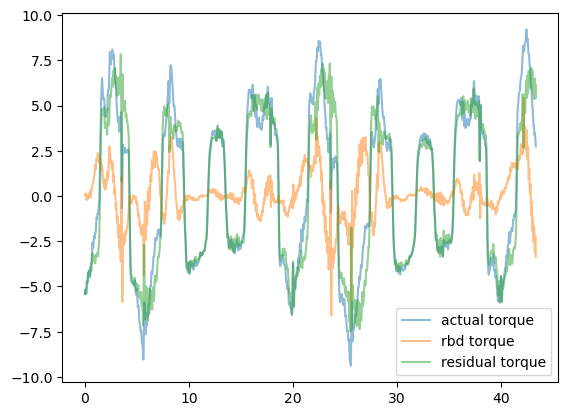

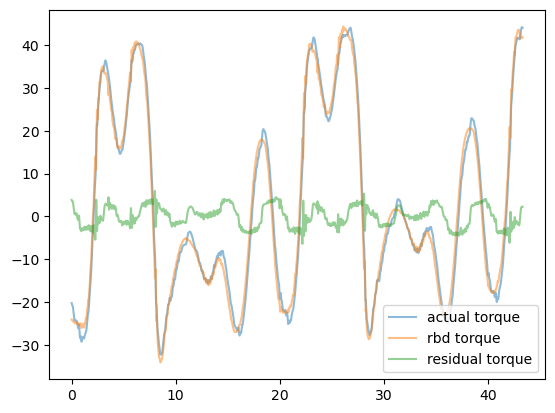

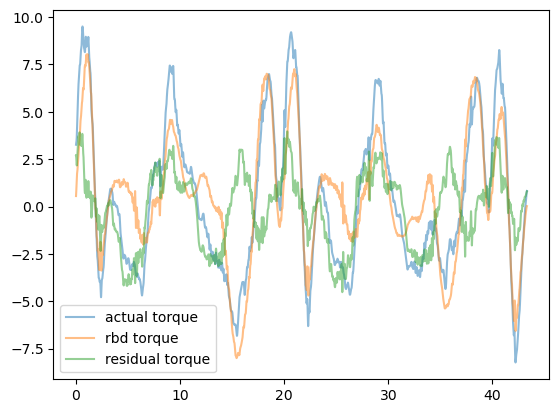

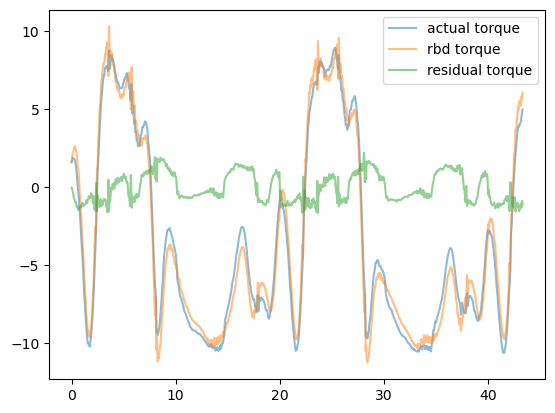

In [58]:
######################################
# Visualize the torques in each joint #
######################################

from matplotlib import pyplot as plt
plt.close()

print("tau_rbd.shape", tau_rbd.shape)
print("tau_vec.shape", tau_vec.shape)
tau_vec = tau_vec.reshape(-1,rbt.dof)
tau_rbd = tau_rbd.reshape(-1,rbt.dof)
tau_residual = tau_residual.reshape(-1,rbt.dof)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    plt.plot(t, tau_vec[:,i], alpha = 0.5, label='actual torque') # actual torque
    plt.plot(t, tau_rbd[:,i],  alpha = 0.5,  label='rbd torque') # modeled by rbd
    plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
    plt.legend()
    plt.show()


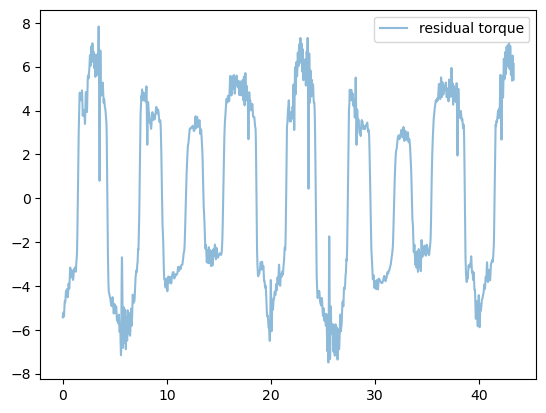

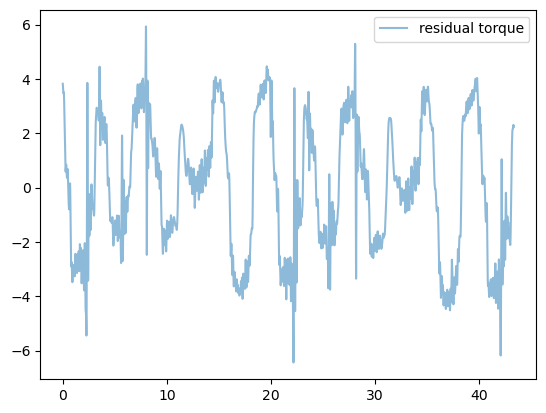

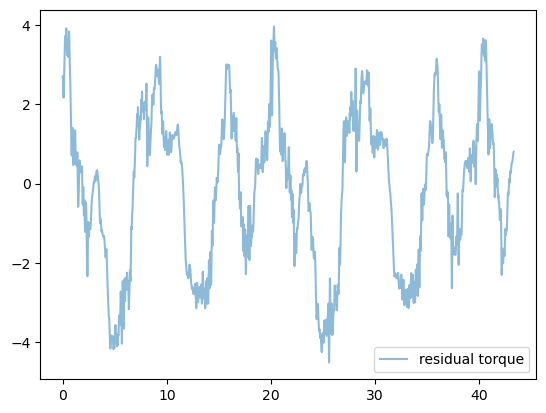

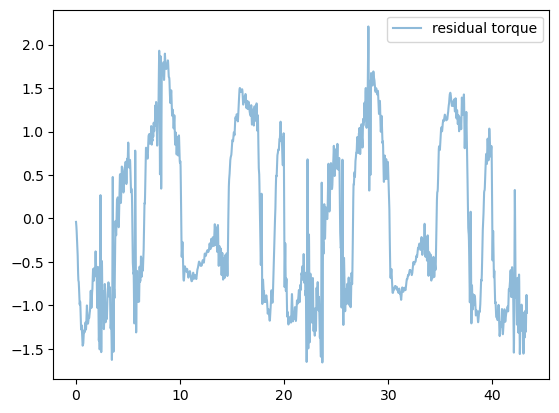

In [59]:
# Visualize only the residual in each joint

# TODO: Do i need to normalize this error when I visualize it?


from matplotlib import pyplot as plt
plt.close()

tau_residual = tau_residual.reshape(-1,rbt.dof)

# one plot for each of the degrees of freedom

for i in range(rbt.dof):
    plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
    plt.legend()
    plt.show()


# Friction Modeling

Here are some useful functions below...

In [60]:
import numpy as np
import sympy as sp
from sklearn.preprocessing import PolynomialFeatures

def generate_regressor(
    q,
    dq,
    ddq,
    basis_type=None,
    poly_deg=2,
    poly_in=None,
    trig_in=None,
    include_bias=False,
    custom_basis_function=None,
    symbols=None
):
    if basis_type is None:
        basis_type = []
    if custom_basis_function is None:
        custom_basis_function = []

    q = np.asarray(q)
    dq = np.asarray(dq)
    ddq = np.asarray(ddq)

    if q.ndim == 1:
        q = q[:, None]
    if dq.ndim == 1:
        dq = dq[:, None]
    if ddq.ndim == 1:
        ddq = ddq[:, None]

    N = q.shape[0]

    if poly_in is None:
        poly_in = (q, dq, ddq)
    if trig_in is None:
        trig_in = (q, dq, ddq)

    basis_populated = []

    for b in basis_type:
        if b == 'Coulomb':
            basis_populated.append(np.sign(dq))
        elif b == 'viscous':
            basis_populated.append(dq)
        elif b == 'poly':
            X_poly = np.concatenate(poly_in, axis=1)
            poly = PolynomialFeatures(degree=poly_deg, include_bias=False)
            basis_populated.append(poly.fit_transform(X_poly))
        elif b == 'trig':
            X_trig = np.concatenate(trig_in, axis=1)
            basis_populated.append(np.concatenate([np.sin(X_trig), np.cos(X_trig)], axis=1))
        else:
            raise ValueError(f"Unknown basis type: {b}")

    if custom_basis_function:
        if symbols is None:
            raise ValueError("symbols must be provided for custom basis")

        ddq_symbol, dq_symbol, q_symbol = symbols

        compiled_basis = [
            sp.lambdify((ddq_symbol, dq_symbol, q_symbol), expr, modules="numpy")
            for expr in custom_basis_function
        ]

        for f in compiled_basis:
            val = np.asarray(f(ddq, dq, q))
            if val.ndim == 1:
                val = val[:, None]
            basis_populated.append(val)

    if include_bias:
        basis_populated.append(np.ones((N, 1)))

    Phi = np.concatenate(basis_populated, axis=1)
    return Phi

In [64]:
def trial(basis_in, symbols=None):
        # get the regressor matrix 
    if symbols is None:
        Phi = generate_regressor(q,dq,ddq, basis_type=basis_in)
    else:
        Phi = generate_regressor(q, dq, ddq, custom_basis_function=basis_in, symbols=symbols)

    tau_res = tau_residual.reshape(Phi.shape[0], -1)
    print("Phi.shape", Phi.shape)
    print("tau_res.shape", tau_res.shape)    
    
    beta_hat, *_ = np.linalg.lstsq(Phi, tau_res, rcond=None)
    
    tau_residual_hat = Phi @ beta_hat
    
    print("tau_residual_hat", tau_residual_hat)
    print("beta_hat", beta_hat)
    
    residual_hat = tau_res - tau_residual_hat
    
    rmse_hat = np.sqrt(np.mean(np.square((residual_hat))))
    print("rmse_hat", rmse_hat)
    
    trials_beta.append(beta_hat)
    trials_rmse.append(rmse_hat)
    trials_basis_type.append(basis_in)
    trials_tau_residual_hat.append(tau_residual_hat)
    return rmse_hat

In [96]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################

def plot_trials_residuals():
        
    from matplotlib import pyplot as plt
    plt.close()

    for _i in range(len(trials_tau_residual_hat)):
        trial_tau_residual_hat = trials_tau_residual_hat[_i].reshape(-1,rbt.dof)
        
    
        for i in range(rbt.dof):
            plt.plot(t, tau_residual[:,i],  alpha = 0.5,  label='residual torque') # actual torque
            plt.plot(t, trial_tau_residual_hat[:,i], label='predicted residual torque') # residual torque
            plt.legend()

            plt.title(f"torque residual {trials_basis_type[_i]}")
            plt.show()
        

In [113]:
####################################
## RESIDUAL + RBD compare to TRUE ##
####################################


def plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec, joints_range=range(rbt.dof)):
 
    from matplotlib import pyplot as plt
    plt.close()
    
    print("tau_rbd.shape", tau_rbd.shape)
    print("tau_vec.shape", tau_vec.shape)

      
    # one plot for each of the degrees of freedom
    
    for i in joints_range:
        
        tau_reconstructed = tau_residual_prediction[:,i] + tau_rbd[:,i]
        tau_residual_prediction_error = tau_residual[:,i] - tau_residual_prediction[:,i]

        plt.plot(t, tau_vec[:,i], alpha = 0.5, label='actual torque') # actual torque
        plt.plot(t, tau_reconstructed,  alpha = 0.5,  label='reconstruction torque') # modeled by rbd
        plt.plot(t, tau_residual_prediction_error,  alpha = 0.5,  label='residual modeling error') # actual torque
        plt.legend()
        plt.show()


    
    # torque_reconstructed = tau_residual_prediction + tau_rbd
    # tau_residual = tau_residual.reshape(-1,1)
    
    # from matplotlib import pyplot as plt
    # plt.close()
    
    # print("torque_reconstructed.shape", torque_reconstructed.shape)
    # print("tau_vec.shape", tau_vec.shape)
    
    # # one plot for each of the degrees of freedom
    
    # for i in range(joints_range):
    #     steps = tau_vec.shape[0]
    #     j = steps//rbt.dof
    
    #     plt.plot(t, tau_vec[j*i:j*(i+1)], alpha = 0.5, label='actual torque') # actual torque
    #     plt.plot(t, torque_reconstructed[j*i:j*(i+1)],  alpha = 0.5,  label='reconstructed torque') # modeled by rbd
    #     plt.plot(t, (tau_residual_prediction-tau_residual)[j*i:j*(i+1)],  alpha = 0.5,  label='residual torque modeling error') # actual torque
        
       
    #     plt.legend()
    #     plt.show()

## Friction Modeling Preliminary Work

Here we do naive modeling with polynomial, trig, and mixed bases to see what works, what doesn't... 

torque_motor = torque_rbd + torque_residual,
(which in the notation used here, torque is represented by tau)
where torque_residual = friction terms (coriolis, stiction, other friction terms that have not been included in the rbd) + other residual terms (noise, unknown)

RESULTS:
Modeling RBD with viscous friction included only:

RESULTS:
Modeling RBD with viscous friction included only:

trial_basis_type = [['trig'], ['Coulomb', 'trig', 'poly'], ['Coulomb'], ['poly']]

trials_rmse = [0.8670458786974545, 0.3138979929164579, 1.0090682468294507, 0.459470230997185]

trials_beta_size = [25, 119, 5, 91]


In [88]:
#get the velocities and accelerations
# q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
#                                fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error

print(q.shape)
print(dq.shape)
print(ddq.shape)

trials_rmse = [] #the error between tau_residual and tau_residual_pred (float)
trials_beta = [] #the regressor vector used (each trial may have a different size of regressor vector)
trials_basis_type = []
trials_tau_residual_hat = []
#after we have all trials we can also get the number of weights used to see the complexity of the model : - )

#just gonna hard code some reusable terms for my convenience here. add experimental things in 'custom'

# poly_deg = 2

# poly = PolynomialFeatures(degree=deg, include_bias=True)

# trig = 

# # add any trial type to test to append those terms to the regression basis.
# # this is kind of a manual process so just double check the degree for poly/trig/custom etc.
# basis_types = {'Coulomb':f_c_vec, 'viscous':f_v_vec, 'poly':poly, 'trig':trig, 'custom':custom}

# regressor_vec = np.array([

(10829, 4)
(10829, 4)
(10829, 4)


In [89]:
# Trial
fp="poly"
fC="Coulomb"
ft="trig"
fv="viscous"
ftp = 'trig_poly'

# basis_types = [[fp],[fC],[ft],[fp,fC],[fp,ft],[fC,ft],[fp,fC,ft]]
basis_types = [[ft],[fC, ft, fp], [fC],[fp],[ft], [fv, fC]]
# Phi beta = torque_residual

tau_residual= tau_residual.reshape(-1,rbt.dof)

for b in basis_types:
    trial(b)

Phi.shape (10829, 24)
tau_res.shape (10829, 4)
tau_residual_hat [[-4.77770442  3.65145639  2.80421629 -0.02685516]
 [-4.77751614  3.65398933  2.82255074 -0.03104245]
 [-4.76938443  3.642416    2.8308422  -0.03707332]
 ...
 [ 6.41673315  2.55547978 -0.85541863 -0.62419507]
 [ 6.44784862  2.53411226 -0.84687484 -0.63412628]
 [ 6.48059013  2.50980918 -0.83289631 -0.64760284]]
beta_hat [[ 2.04245470e-01  4.38954158e-01 -1.57084206e-01 -1.62982723e-01]
 [-5.59283173e-01  8.22575051e-01  1.26571345e+00  1.29086033e-01]
 [-6.61714865e-03 -4.09930644e-01  1.75731230e-02 -8.71425024e-02]
 [ 1.09405376e+00  4.53817499e-01 -1.17124721e+00  4.06838064e-01]
 [ 7.03770327e+00  1.20330599e+00  1.74135903e-01  3.31550466e-01]
 [-1.60471012e-01  4.59733788e+00 -3.09553954e-01 -4.82052434e-01]
 [ 1.12989643e+00  1.68824120e-01  2.71652090e+00  4.13393920e-01]
 [-5.83080417e-01 -1.35496846e+00 -4.22108612e-02  1.26854572e+00]
 [ 5.58184066e-01 -1.08929764e-01  3.90095221e-01 -2.21321237e-01]
 [-5.4167553

In [90]:
trials_rmse

[0.8565289013860068,
 0.3127575373417296,
 1.1854505434051823,
 0.4852877491910191,
 0.8565289013860068,
 0.8078995477809189]

In [91]:
trials_basis_type

[['trig'],
 ['Coulomb', 'trig', 'poly'],
 ['Coulomb'],
 ['poly'],
 ['trig'],
 ['viscous', 'Coulomb']]

In [92]:
for t_b in trials_beta:
    print(t_b.shape)

(24, 4)
(118, 4)
(4, 4)
(90, 4)
(24, 4)
(8, 4)


In [93]:
trials_tau_residual_hat

[matrix([[-4.77770442,  3.65145639,  2.80421629, -0.02685516],
         [-4.77751614,  3.65398933,  2.82255074, -0.03104245],
         [-4.76938443,  3.642416  ,  2.8308422 , -0.03707332],
         ...,
         [ 6.41673315,  2.55547978, -0.85541863, -0.62419507],
         [ 6.44784862,  2.53411226, -0.84687484, -0.63412628],
         [ 6.48059013,  2.50980918, -0.83289631, -0.64760284]]),
 matrix([[-5.58336818,  3.61911   ,  2.91163862, -0.13092488],
         [-5.5950624 ,  3.65035916,  2.91077902, -0.13188416],
         [-5.61041228,  3.67929103,  2.90159304, -0.12947516],
         ...,
         [ 4.98460313,  1.59485845,  0.54190741, -1.24148923],
         [ 5.07279903,  1.59744964,  0.55445024, -1.26289946],
         [ 5.16403278,  1.6049705 ,  0.56979929, -1.28079341]]),
 matrix([[-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         [-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         [-3.87469318,  2.1716149 ,  1.52327169, -0.85763302],
         ...,
         

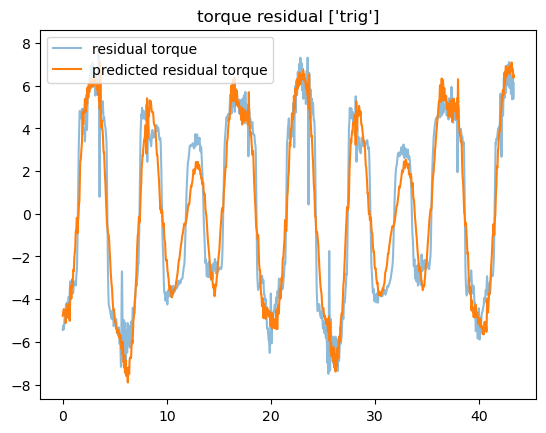

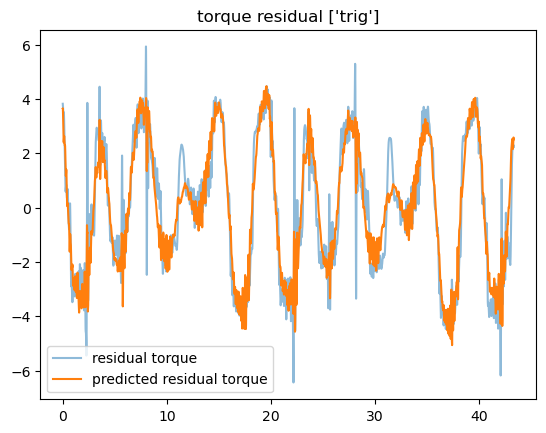

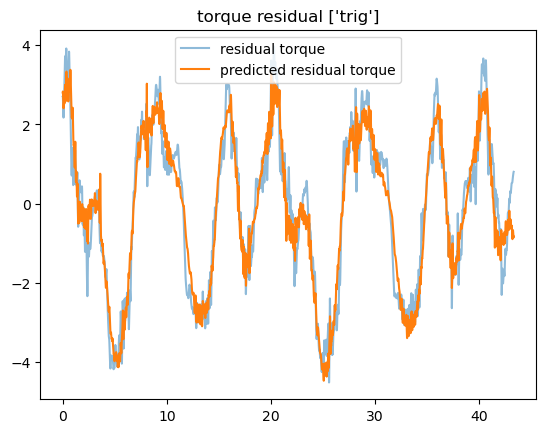

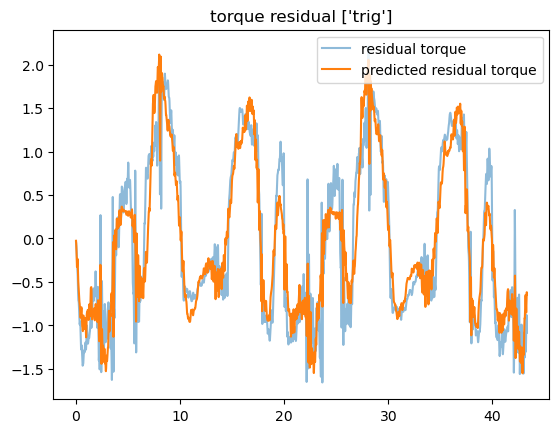

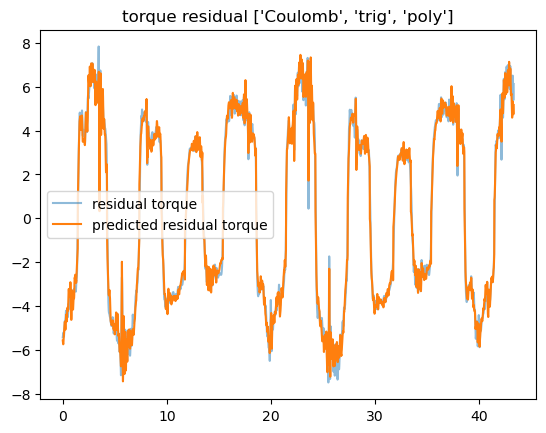

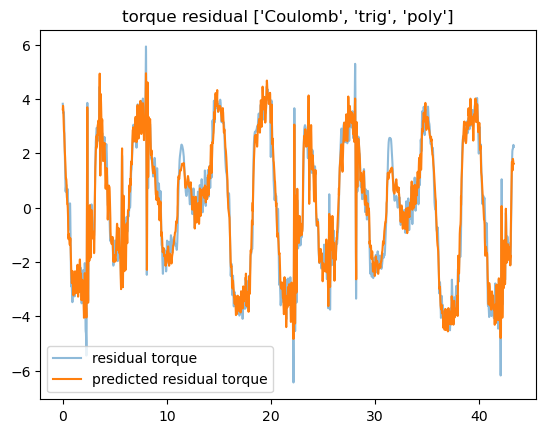

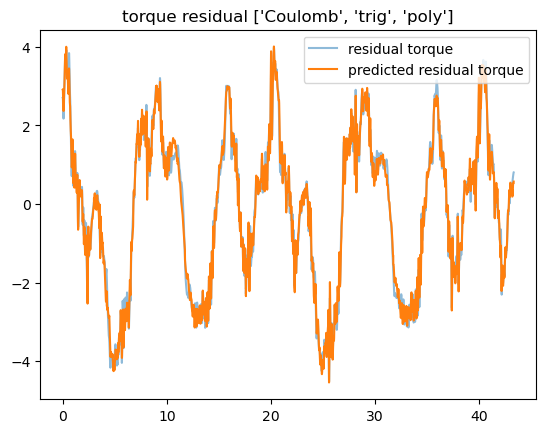

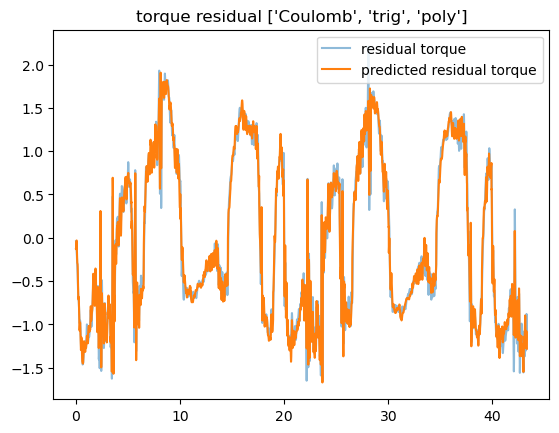

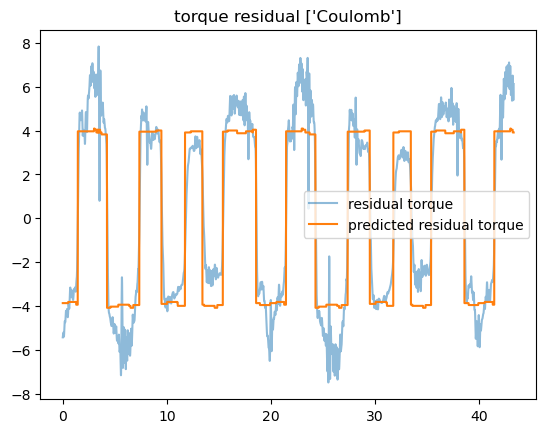

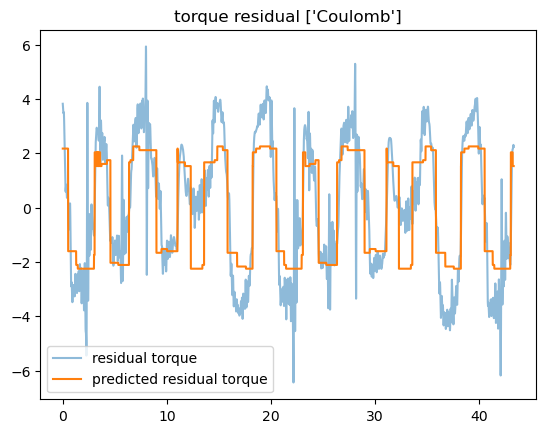

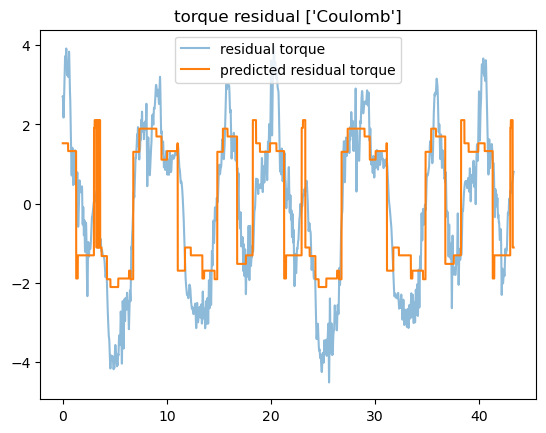

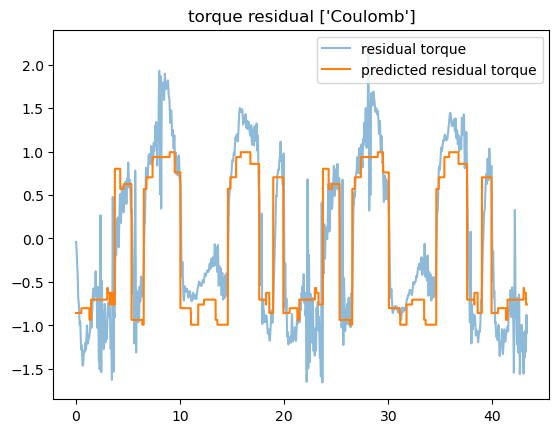

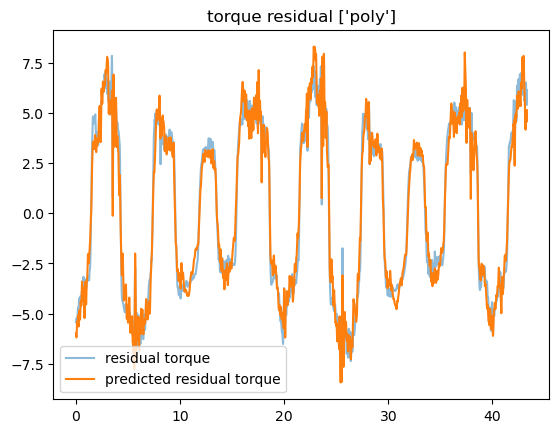

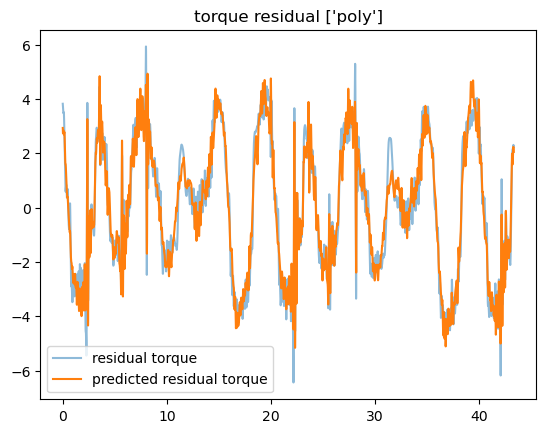

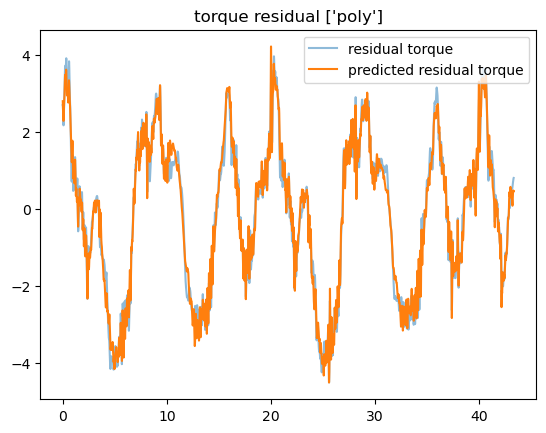

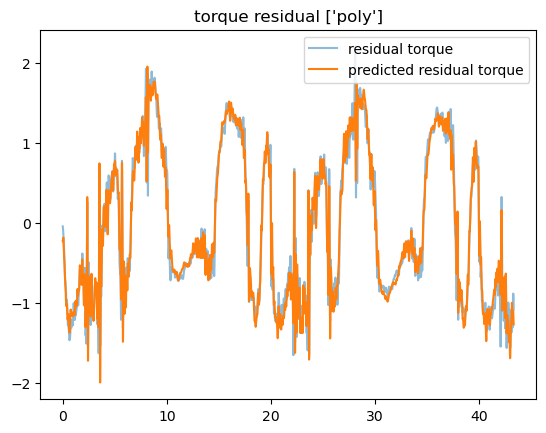

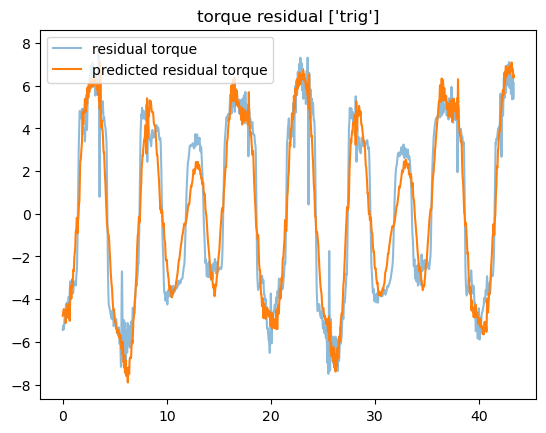

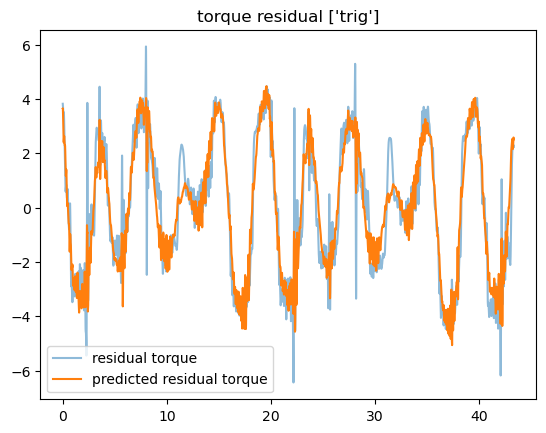

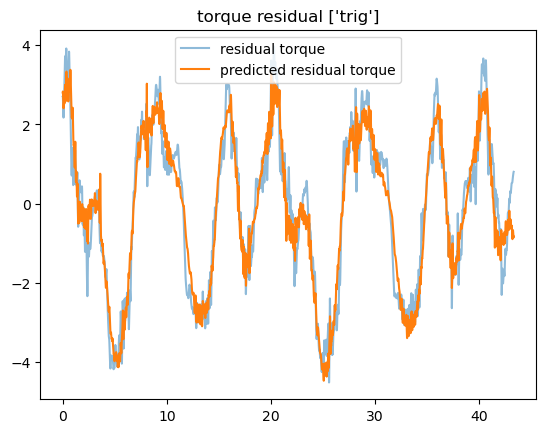

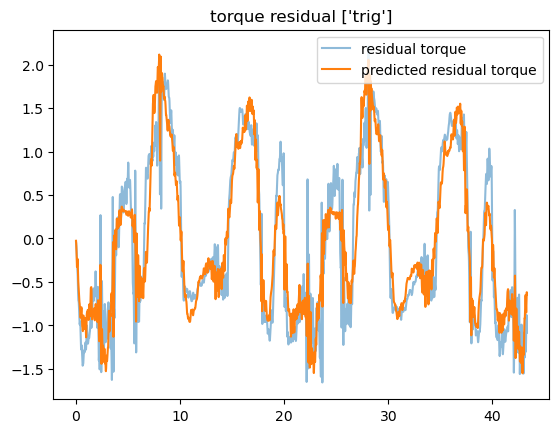

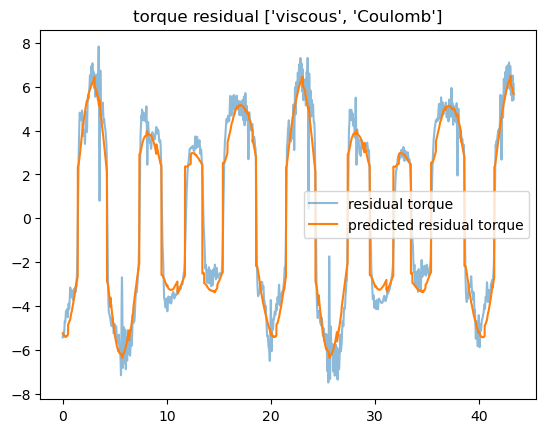

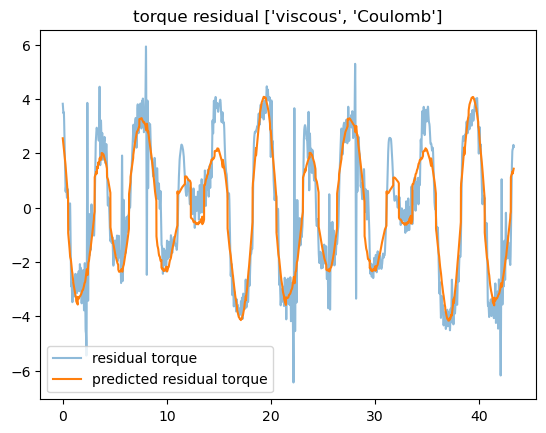

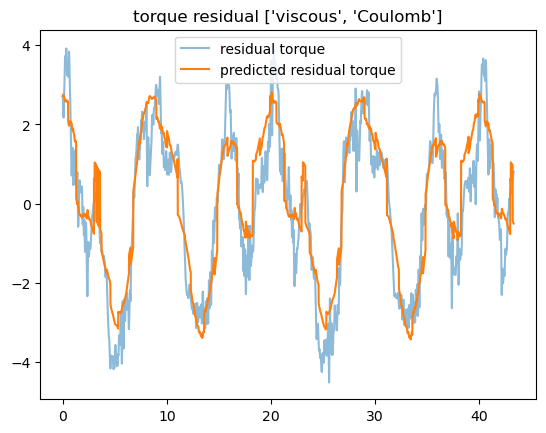

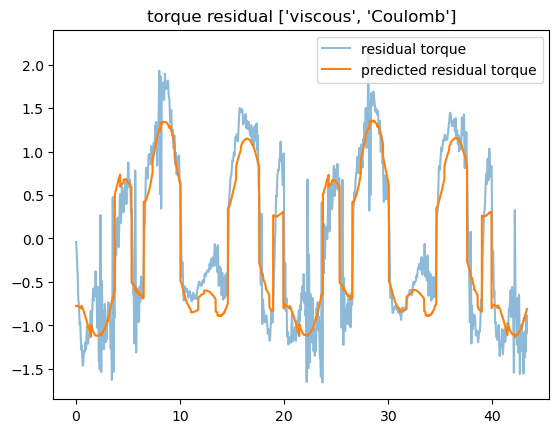

In [97]:
plot_trials_residuals()

#################################################
FFRL_RT_NRE_basis_3
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


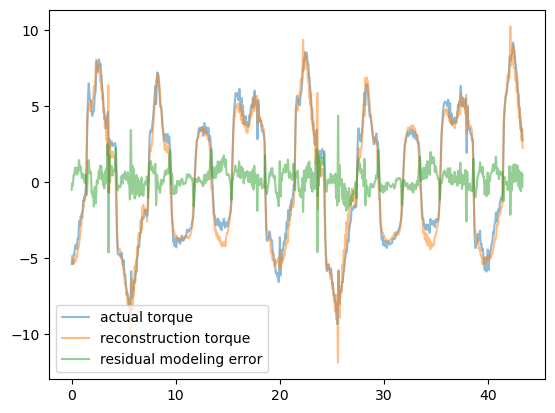

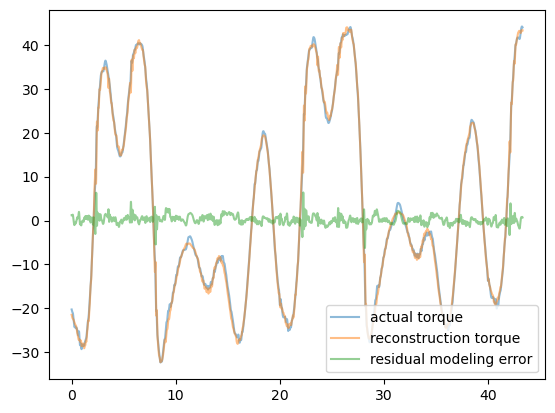

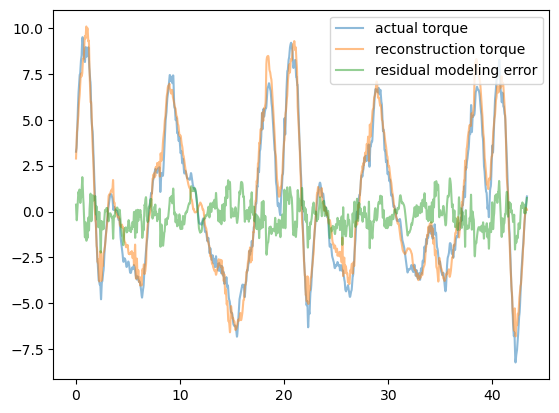

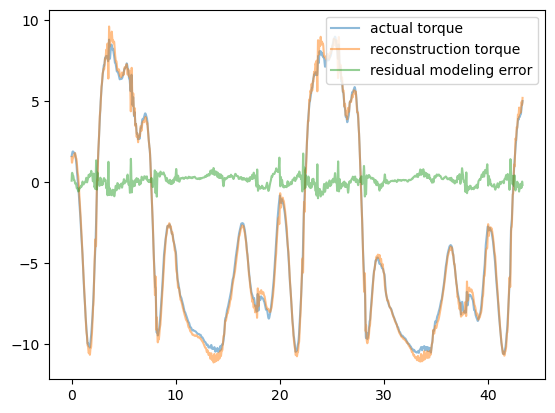

#################################################
FFRL_RT_NRE_basis_4
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


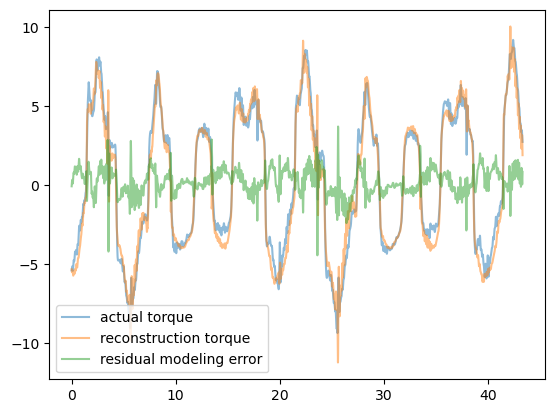

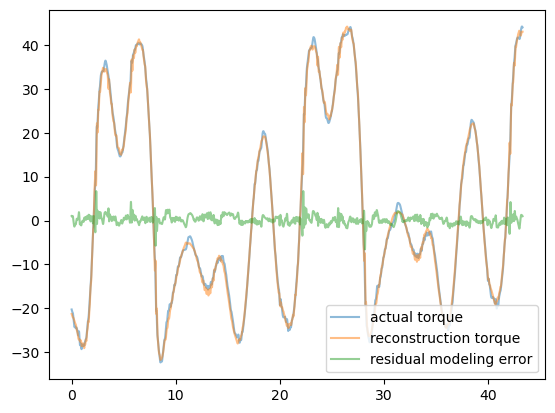

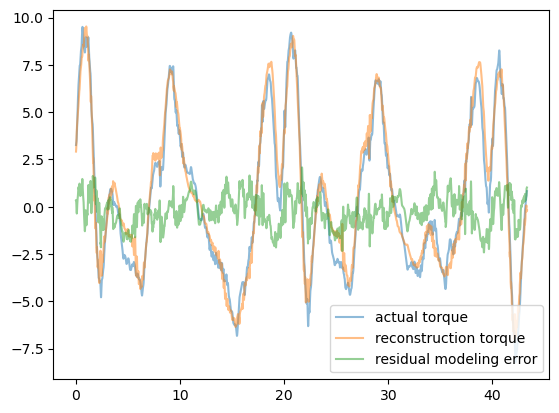

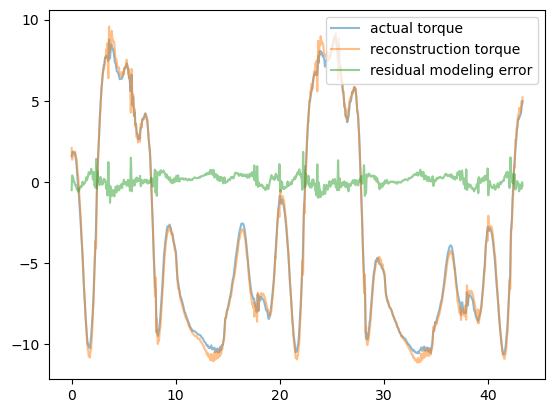

#################################################
FFRL_RT_NRE_basis_5
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


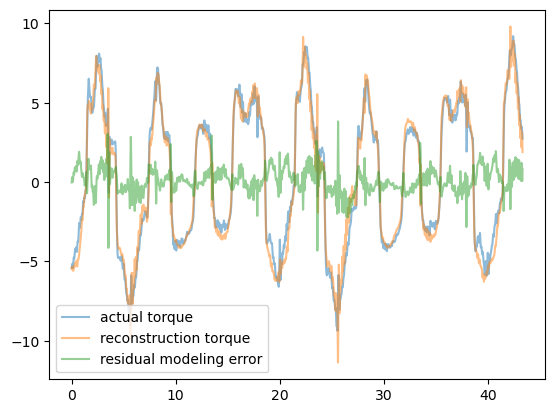

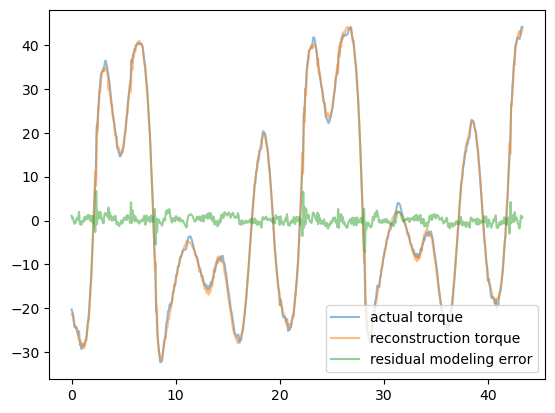

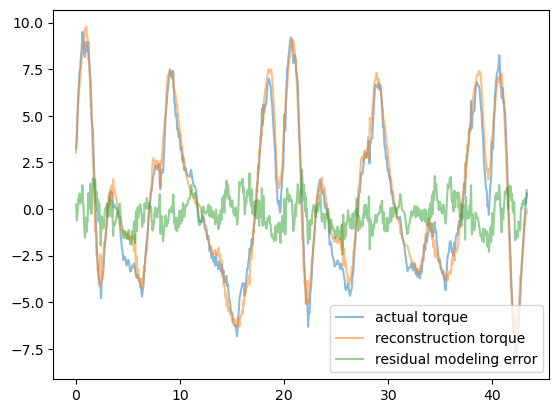

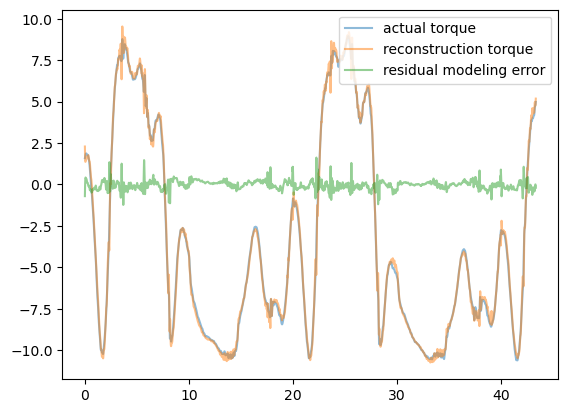

In [129]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################
for i in range(len(trials_tau_residual_hat)):
    tau_residual_prediction = trials_tau_residual_hat[i]
    
    print("#################################################")
    print(trials_basis_type[i])
    print("#################################################")
    tau_vec = tau_vec.reshape(-1,rbt.dof)
    tau_rbd = tau_rbd.reshape(-1,rbt.dof)
    tau_residual = tau_residual.reshape(-1,rbt.dof)
    tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)
    plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec)
  
        

In [246]:
tau_residual

matrix([[-5.43679426,  3.82192288,  2.70928193, -0.03956959],
        [-5.41687581,  3.80678188,  2.70862374, -0.04771417],
        [-5.39664524,  3.78724515,  2.69756409, -0.05460681],
        ...,
        [ 5.87929311,  2.26319962,  0.79597169, -1.02786948],
        [ 6.00162542,  2.2460603 ,  0.79920616, -1.05742611],
        [ 6.12066706,  2.22883788,  0.80227082, -1.08408357]])

## A Friction-model-based Framework for Reinforcement Learning of Robotic Tasks in Non-rigid Environments (FFRL_RT_NRE)
Colome et al

This paper uses a novel friction model for each of the joints of the robot:
>>
F^{i}_{fric} = 
 b1 * qi + b2 * dqi + b3 * atan(s * dqi ̇+ z * sign(ddqi))
+0.5 * (1 + sign(dqi))(b4 * f1 + b5 * f2 + b6 * f3 + b7 * f4 + b8 * f5)
+0.5(1 − sign(dqi))(b9 * f1 + b10 * f2 + b11 * f3 + b12 * f4 + b13 * f5),
for i = 1..7,


where 
>>
f_j = (4/pi) * sin((2*j - 1) * h * qi) / (2 * j - 1), j=1..5
are sine Fourier basis functions.

AX=B
A: N, basis_size
X: basis_size, dof
B: N, dof ==> B is the predicted torques, where B[:,j] for each j in range(dof) is the torque for each joint


In [115]:
# get the velocities and accelerations
q, dq, ddq, tau = diff_and_filt_data(dof=rbt.dof, h=rec_h,  q_raw=q_raw, tau_raw=tau_raw,
                               fc_q=fc_q, fc_dq=fc_dq, fc_ddq=fc_ddq, fc_tau=fc_tau)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error

print(q.shape)
print(dq.shape)
print(ddq.shape)
print(tau.shape)
print(tau_residual.shape)

# reset the trials logging
trials_rmse = [] #the error between tau_residual and tau_residual_pred (float)
trials_beta = [] #the regressor vector used (each trial may have a different size of regressor vector)
trials_basis_type = []
trials_tau_residual_hat = []
trials_params_count = []

import sympy as sp
symbols = sp.symbols('ddq, dq, q')


(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)
(10829, 4)


In [116]:
symbols

(ddq, dq, q)

In [117]:
# FFRL_RT_NRE_basis_3
##### Friction is modeled with an initial model as Fifric = b1 * atan(s * dqi) + b2 * dqi)
from sympy import atan

best_J = np.inf
best_s = None
best_b = None
s_grid = np.linspace(20,70,100)

F= tau_residual.reshape(-1,rbt.dof)

# find the best s value
for s in s_grid:   # log-spaced positive values
    X = np.column_stack([np.arctan(s * dq), dq])
    b, *_ = np.linalg.lstsq(X, F, rcond=None)
    J = np.sqrt(np.mean(np.square(F - X @ b)))
    
    if J < best_J:
        best_J = J
        best_s = s
        best_b = b

# print("s_grid:", s_grid)
print("best s:", best_s)
print("best J:", best_J)
print("best b:", best_b)

ddq_symbol = symbols[0]
dq_symbol = symbols[1]
q_symbol = symbols[2]
FFRL_RT_NRE_basis_3 = [atan(best_s*dq_symbol), dq_symbol]

trial(basis_in=FFRL_RT_NRE_basis_3, symbols=symbols)
trials_basis_type[-1]='FFRL_RT_NRE_basis_3'
trials_params_count.append(3*rbt.dof)

chunks_tau_residual_pred = np.array_split(tau_residual-trials_tau_residual_hat[-1], rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))
print("RMSE joint 0:", rmse_joint_0)

##### CONS: "This model not only is independent from position but has no hysteresis value"

best s: 44.24242424242424
best J: 0.7475733263388146
best b: [[ 2.15727949  0.13766596  0.05127145  0.06686193]
 [-0.06475543  0.52645638  0.28311398 -0.02650805]
 [ 0.20503592  0.11354211  0.70928129 -0.00524328]
 [ 0.02067556  0.07195344 -0.15196623  0.45617022]
 [ 1.79998428 -0.02467637 -0.04308958 -0.04822614]
 [ 0.6230785   2.76038161 -1.20315368 -0.12966391]
 [-0.07752312 -0.38900088  1.58061099  0.02624998]
 [-0.60161022 -0.52739733  0.12365675  0.43492621]]
Phi.shape (10829, 8)
tau_res.shape (10829, 4)
tau_residual_hat [[-4.92749673  2.61132384  2.33662644 -0.10821943]
 [-4.95391955  2.58636583  2.38070804 -0.20497054]
 [-4.97988058  2.56179425  2.4237425  -0.29879363]
 ...
 [ 5.65419042  1.52835903  0.10242613 -0.88937652]
 [ 5.6450371   1.53450989  0.08554953 -0.88931295]
 [ 5.63623285  1.53983543  0.0686727  -0.88930687]]
beta_hat [[ 2.15727949  0.13766596  0.05127145  0.06686193]
 [-0.06475543  0.52645638  0.28311398 -0.02650805]
 [ 0.20503592  0.11354211  0.70928129 -0.005

In [118]:
# FFRL_RT_NRE_basis_4
##### Hysteresis is added; acceleration is considered

import numpy as np
import sympy as sp
# utilize scipy least squares
from scipy.optimize import least_squares

tau_residual = tau_residual.reshape(-1,rbt.dof)
joint_params = []

#residual function
def residual_function(params, inputs, outputs):
    b1, b2, s, z = params
    ddq, dq = inputs
    prediction = b1 * np.arctan(s * dq + z * np.sign(ddq)) + b2 * dq
    prediction=prediction.reshape(-1,1)
    return np.ravel(prediction - outputs)

initial_guesses = np.random.uniform(-100,100,(100,4))


for j in range(rbt.dof):
    best_cost_j = np.inf
    best_params_j = None

    inputs = (ddq[:, j], dq[:, j])
    outputs = tau_residual[:, j]
    print(tau_residual.shape)
    print(outputs.shape)

    for ig in initial_guesses:
        res = least_squares(residual_function, ig, args=(inputs, outputs))
        if res.cost < best_cost_j:
            best_cost_j = res.cost
            best_params_j = res.x.copy()

    joint_params.append(best_params_j)

joint_params = np.array(joint_params)
print("joint params:", joint_params)

import numpy as np
tau_residual=tau_residual.reshape(-1,rbt.dof)
N, dof = tau_residual.shape
tau_pred = np.zeros_like(tau_residual, dtype=float).reshape(-1,dof)
print("tau_pred shape:", tau_pred.shape)
print("tau_pred[:,0] shape:", tau_pred[:,0].shape)

for j in range(dof):
    b1_j, b2_j, s_j, z_j = joint_params[j]

    dq_j = dq[:, j]
    ddq_j = ddq[:, j]

    tau_pred[:, j] = (
        b1_j * np.arctan(s_j * dq_j + z_j * np.sign(ddq_j))
        + b2_j * dq_j
    ).reshape(-1,1)

print(tau_residual.shape)
    
rmse_total = np.sqrt(np.mean(np.square((tau_residual - tau_pred))))

trials_rmse.append(rmse_total)
trials_basis_type.append('FFRL_RT_NRE_basis_4')
trials_params_count.append(joint_params.size)
trials_tau_residual_hat.append(tau_pred.reshape(-1,rbt.dof))

chunks_tau_residual_pred = np.array_split(tau_residual-tau_pred, rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))
print("RMSE joint 0:", rmse_joint_0)


print("total RMSE:", rmse_total)

(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
(10829, 4)
(10829, 1)
joint params: [[ 1.98295777e+00  1.84538146e+00  7.88101636e+01 -5.77550240e-01]
 [-9.47504991e-01  1.81815999e+00 -6.67492163e+00 -1.58721727e-01]
 [ 1.54653261e+01 -7.95176888e+00  8.10274717e-01 -1.07792375e-02]
 [ 4.64187602e-01  3.37537187e-01  7.36752332e+01 -1.35458734e+00]]
tau_pred shape: (10829, 4)
tau_pred[:,0] shape: (10829, 1)
(10829, 4)
RMSE joint 0: 0.8312807921885749
total RMSE: 0.7861854025219165


In [119]:
joint_params.size

16

In [120]:
# FFRL_RT_NRE_basis_5

import numpy as np

def sine_fourier_basis(q, h, n_terms=5): # generated for one joint
    # print(q)
    q = np.asarray(q).reshape(-1)
    cols = []
    for j in range(1, n_terms + 1):
        fj = (4 / np.pi) * np.sin((2*j - 1) * h * q) / (2*j - 1)
        cols.append(fj[:, None])
    return np.hstack(cols)   # shape (N, n_terms) # [f1, f2, f3, f4, f5]

In [121]:
# FFRL_RT_NRE_basis_5

def gated_sine_fourier_basis(q, dq, h, n_terms=5): # in the paper they indicate that seperate fourier basis necessary for sign of velocity
    q = np.asarray(q).reshape(-1)
    dq = np.asarray(dq).reshape(-1)

    F = sine_fourier_basis(q, h, n_terms=n_terms)   # (N, 5)

    g_pos = 0.5 * (1 + np.sign(dq))   # (N,)
    g_neg = 0.5 * (1 - np.sign(dq))   # (N,)

    F_pos = F * g_pos[:, None]
    F_neg = F * g_neg[:, None]

    return F_pos, F_neg

In [122]:
# FFRL_RT_NRE_basis_5

def build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=5):
    q = np.asarray(q).reshape(-1)
    dq = np.asarray(dq).reshape(-1)
    ddq = np.asarray(ddq).reshape(-1)

    atan_col = np.arctan(s * dq + z * np.sign(ddq))[:, None]
    q_col = q[:, None]
    dq_col = dq[:, None]

    F_pos, F_neg = gated_sine_fourier_basis(q, dq, h, n_terms=n_terms)

    X = np.hstack([
        q_col,          # b1
        dq_col,         # b2
        atan_col,       # b3
        F_pos,          # b4...b8
        F_neg           # b9...b13
    ])
    return X

In [123]:
# FFRL_RT_NRE_basis_5

'''
for grid in values get the somewhat estimate of h,s,z for each joint. then we can do scipy optimize around that area for each joint.
below is the function to do so for ONE joint
'''

def single_joint_torque_compute_FFRL_RT_NRE_basis_5(q, dq, ddq, B, n_fourier_terms=5):
    '''returns the appropriate h,s,z for that one joint. make sure you slice q,dq,ddq, and tau_residual as B'''
    z_grid = np.linspace(0,5,10)
    s_grid = np.linspace(0,100,10)
    h_grid = np.linspace(-10,10,10)
    best_rmse = np.inf
    for z in z_grid:
        for s in s_grid:
            for h in h_grid:
                X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
                # print("X shape:", X.shape) # should be (N, 13), if N is the number of joint samples, counting each joint config as 1 sample
                # AX=B
                b , *_ = np.linalg.lstsq(X, B, rcond=None)
                pred = X@b
                rmse = np.sqrt(np.mean(np.square(B - pred)))
                # print("X shape:", X.shape)   # should be (N, 13)
                # print("b shape:", b.shape)   # should be (13,)
                # print("rmse:", rmse)
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_h = h
                    best_z = z
                    best_s = s
                    best_b = b.copy()

    # now stage 2: found the best in the grid, now use scipy optimize to hone in
    #residual function
    def residual_function(params, inputs, outputs):
        b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, s, z, h = params
        b_vec = np.array([b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13])
        ddq, dq, q = inputs
        X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
        prediction = np.dot(X,b_vec)
        prediction=prediction.reshape(-1,1)
        # print(prediction)
        # print("prediction shape:", prediction.shape)
        
        return np.ravel(prediction - outputs)

    initial_guess = (*best_b, best_s, best_z, best_h)
    inputs = (ddq, dq, q)
    outputs = B
    res = least_squares(residual_function, initial_guess, args=(inputs, outputs))
    best_params_j = res.x.copy()

    b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13, s, z, h = best_params_j
    b = np.array([b1, b2, b3, b4, b5, b6, b7, b8, b9, b10, b11, b12, b13])

    X = build_advanced_friction_regressor(q, dq, ddq, s, z, h, n_terms=n_fourier_terms)
    
    prediction = np.dot(X,b)
    
    return best_params_j, prediction
    


In [124]:
# FFRL_RT_NRE_basis_5
tau_residual = tau_residual.reshape(-1, rbt.dof)

tau_residual=tau_residual.reshape(-1,rbt.dof)
N, dof = tau_residual.shape
tau_pred = np.zeros_like(tau_residual, dtype=float).reshape(-1,dof)
print("tau_pred shape:", tau_pred.shape)
print("tau_pred[:,0] shape:", tau_pred[:,0].shape)

params=[]
for j in range(dof):
    q_j = q[:, j]
    dq_j = dq[:, j]
    ddq_j = ddq[:, j]
    F_j = tau_residual[:, j]
    best_params_j, prediction = single_joint_torque_compute_FFRL_RT_NRE_basis_5(q_j, dq_j, ddq_j, F_j)
    if best_params_j is None:
        raise ValueError(f"No valid params found for joint {j}")
    print("best params:\n",best_params_j.shape)
    params.append(best_params_j)
    tau_pred[:, j] = np.asarray(prediction).reshape(-1,1)

params = np.array(params).ravel()
tau_pred = tau_pred.reshape(-1,1)
tau_residual=tau_residual.reshape(-1,1)
rmse_total = np.sqrt(np.mean(np.square((tau_residual - tau_pred))))

chunks_tau_residual_pred = np.array_split(tau_residual-tau_pred, rbt.dof)
rmse_joint_0 = np.sqrt(np.mean(np.square(chunks_tau_residual_pred[0])))

trials_rmse.append(rmse_total)
trials_basis_type.append('FFRL_RT_NRE_basis_5')
trials_params_count.append(len(params))
trials_tau_residual_hat.append(tau_pred.reshape(-1,rbt.dof))

print("total RMSE:", rmse_total)
print("RMSE joint 0:", rmse_joint_0)

tau_pred shape: (10829, 4)
tau_pred[:,0] shape: (10829, 1)


/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/numpy/lib/type_check.py:340: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  type_ = asarray(x).dtype.type
/home/oliveoil/miniconda3/envs/id/lib/python3.8/site-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


best params:
 (16,)
best params:
 (16,)
best params:
 (16,)
best params:
 (16,)
total RMSE: 0.7475854168452892
RMSE joint 0: 0.7964931543758511


In [125]:
trials_rmse

[0.7475733263388146, 0.7861854025219165, 0.7475854168452892]

In [126]:
trials_params_count

[12, 16, 64]

In [127]:
trials_tau_residual_hat

[matrix([[-4.92749673,  2.61132384,  2.33662644, -0.10821943],
         [-4.95391955,  2.58636583,  2.38070804, -0.20497054],
         [-4.97988058,  2.56179425,  2.4237425 , -0.29879363],
         ...,
         [ 5.65419042,  1.52835903,  0.10242613, -0.88937652],
         [ 5.6450371 ,  1.53450989,  0.08554953, -0.88931295],
         [ 5.63623285,  1.53983543,  0.0686727 , -0.88930687]]),
 matrix([[-5.36545259,  2.8011131 ,  2.3610302 ,  0.46715928],
         [-5.38800366,  2.79329458,  2.35526335,  0.40991313],
         [-5.41021106,  2.78539512,  2.34945397,  0.3297067 ],
         ...,
         [ 5.2908903 ,  1.23295658, -0.20942092, -0.8569188 ],
         [ 5.28420578,  1.24348552, -0.21175193, -0.85677004],
         [ 5.27799078,  1.25283198, -0.21416022, -0.85668786]]),
 matrix([[-5.41563485,  2.7328187 ,  2.46115835,  0.66505461],
         [-5.43248582,  2.76947603,  2.47067857,  0.28887875],
         [-5.44896343,  2.80710672,  2.48082972,  0.22506024],
         ...,
         

#################################################
FFRL_RT_NRE_basis_3
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


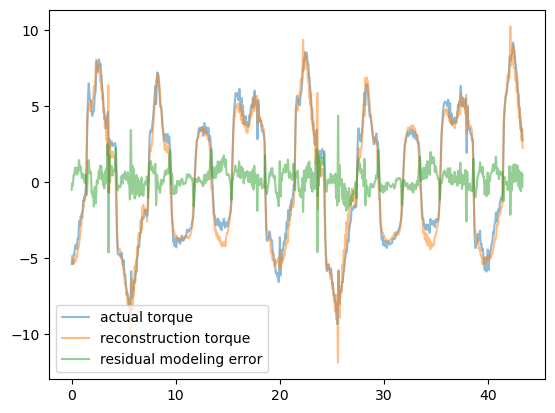

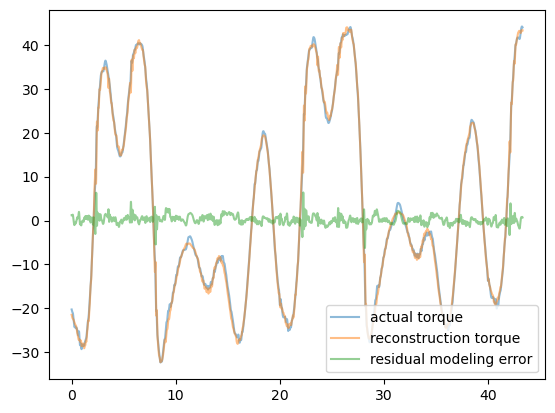

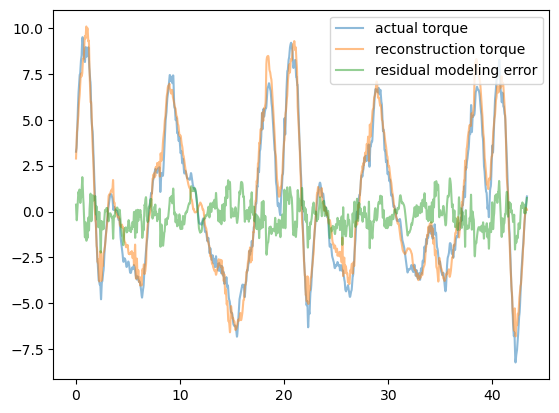

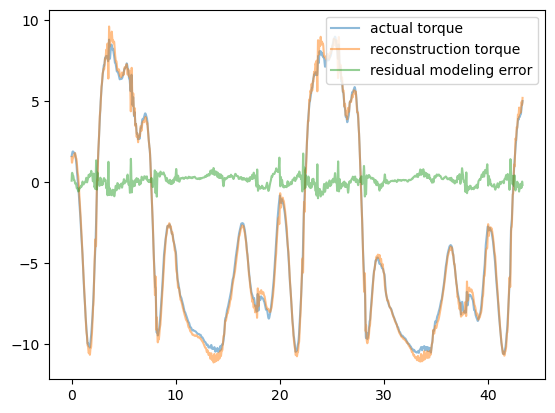

#################################################
FFRL_RT_NRE_basis_4
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


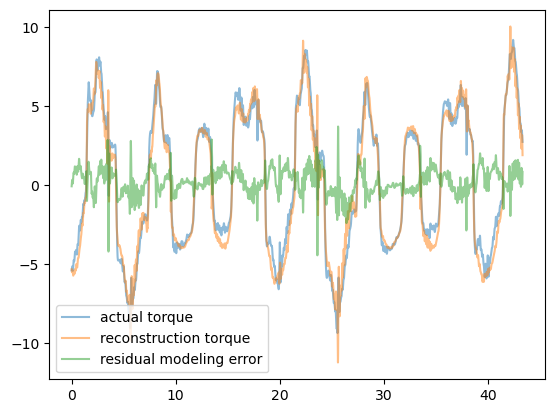

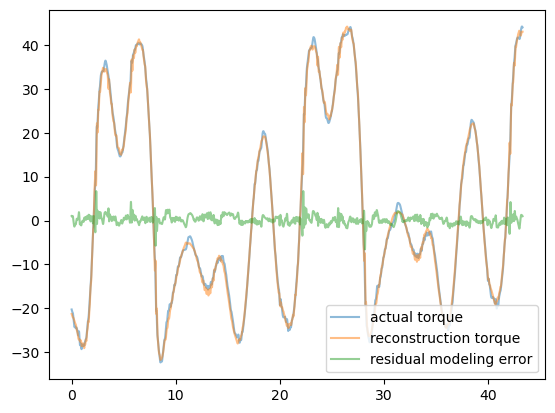

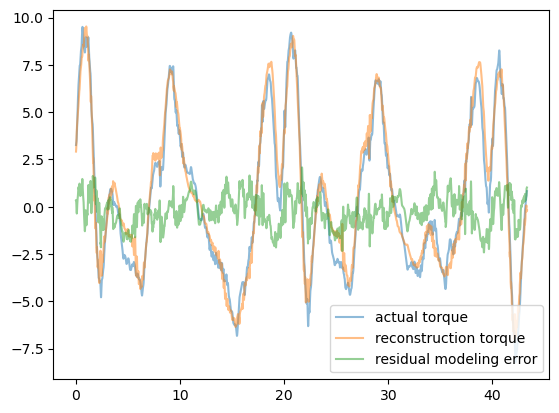

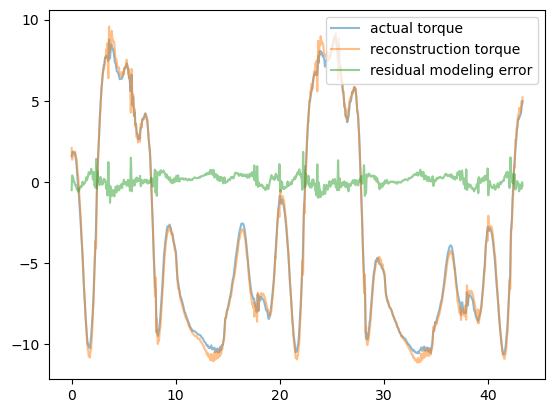

#################################################
FFRL_RT_NRE_basis_5
#################################################
tau_rbd.shape (10829, 4)
tau_vec.shape (10829, 4)


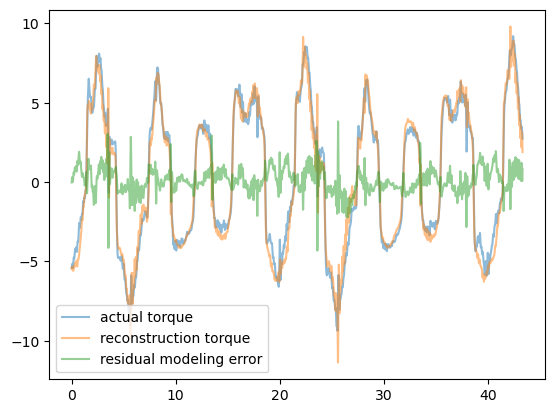

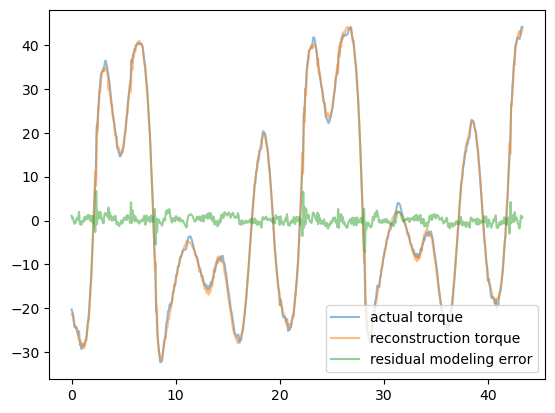

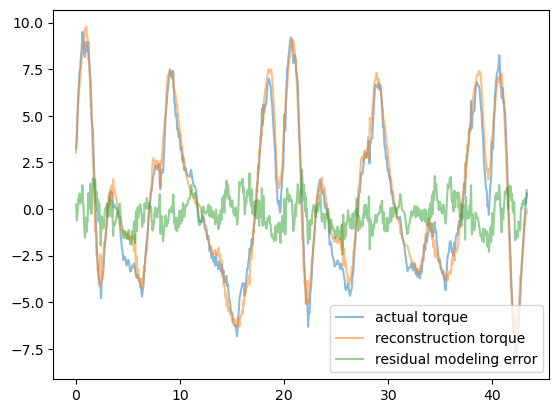

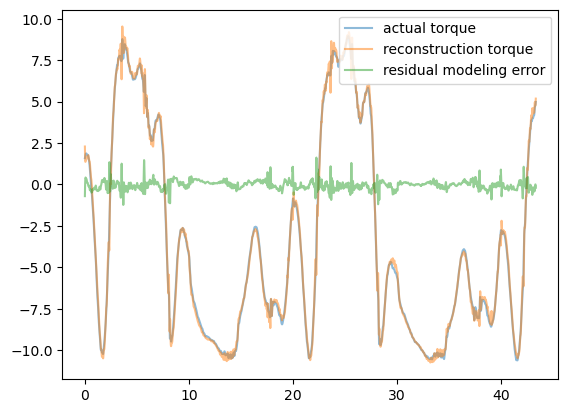

In [128]:
#############################
### PLOT TRIALS RESIDUALS ###
#############################
for i in range(len(trials_tau_residual_hat)):
    tau_residual_prediction = trials_tau_residual_hat[i]
    
    print("#################################################")
    print(trials_basis_type[i])
    print("#################################################")
    tau_vec = tau_vec.reshape(-1,rbt.dof)
    tau_rbd = tau_rbd.reshape(-1,rbt.dof)
    tau_residual = tau_residual.reshape(-1,rbt.dof)
    tau_residual_prediction = tau_residual_prediction.reshape(-1,rbt.dof)
    plot_reconstruction_and_residuals(tau_residual_prediction, tau_residual, tau_rbd, tau_vec)
  
        

# SINDy Methods and Hybrid SINDy

install using `pip install pysindy`
import using `import pysindy as ps`

We use the SINDy library not to solve dynamic equations, but simply for the sparse symbolic regression aspect.

# Sparse Regression 


# SymINDy (Symbolic regression and SINDy algorithms)

pysindy: 1.6.3
sklearn: 1.0.2

utilizes the symindy module that i imported in the same directory as this notebook

In [21]:
from symindy.sym_sparse_regressor import SymSparseRegressor
import numpy as np


In [22]:
np.random.seed(0)

In [31]:
model = SymSparseRegressor(
    dims=3,
    ngen=5,
    ntrees=5,
    n_individuals=100,
    max_depth=3,
    verbose=True,
    regressor_kwargs={
        "alpha": 1e-2,
        "fit_intercept": True,
        "max_iter": 100000,
        "tol": 1e-2,
    },
)

INFO SymSparseRegressor__init__


In [32]:
tau_residual=tau_residual.reshape(-1,rbt.dof)
q_0 = q[:,0]
dq_0 = dq[:,0]
ddq_0 = ddq[:,0]
tau_residual_0 = tau_residual[:,0]
Q_0 = np.column_stack([q_0, dq_0, ddq_0])
print(q_0.shape)
print(Q_0.shape)
print(tau_residual_0.shape)

model.fit(Q_0, tau_residual_0)

(10829,)
(10829, 3)
(10829, 1)
INFO SymSparseRegressor fit
INFO SymSparseRegressor configure_DEAP
Fitness: [-0.3753349821559624]
Fitness: [0.6877857608279169]
Fitness: [0.579561717851415]
Fitness: [0.7598080593093622]
Fitness: [0.809496492981038]
Fitness: [0.7235422902307389]
Fitness: [0.631921417275274]
Fitness: [-0.2914471201452175]
Fitness: [0.8262757926033593]
Fitness: [0.7434659725974077]
Fitness: [0.6884300798785962]
Fitness: [-0.11184222787624645]
Fitness: [0.2584782342697587]
Fitness: [-0.43888354956604436]
Fitness: [0.7076717263347112]
Fitness: [0.5347700910908517]
Fitness: [-0.2256633848758896]
Fitness: [0.7844737060800656]
Fitness: [-0.25572811016216135]
Fitness: [0.8094791644078284]
Fitness: [0.5000071895972525]
Fitness: [-0.1914291242578054]
Fitness: [0.8099544848057718]
Fitness: [0.6442343148223648]
Fitness: [-0.32206682629573224]
Fitness: [0.6999319695058431]
Fitness: [-0.21718759744028357]
Fitness: [-0.33607299568524845]
Fitness: [0.747048182086167]
Fitness: [0.79981479

In [33]:
tau_predict_0 = model.predict(Q_0)

INFO SymSparseRegressor predict


In [133]:
print("R2:", model.score(Q_0, tau_residual_0))

INFO SymSparseRegressor score
INFO SymSparseRegressor predict
R2: 0.8472231234291583


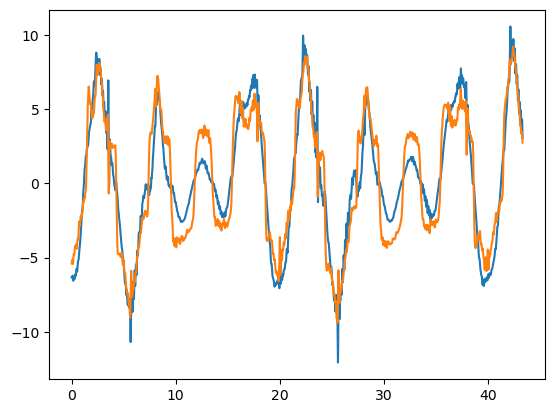

In [135]:
tau_rbd=tau_rbd.reshape(-1,rbt.dof)
tau_vec = tau_vec.reshape(-1,rbt.dof)
plt.plot(t,tau_predict_0 + tau_rbd[:,0])
plt.plot(t,tau_vec[:,0])